构建 Hamitonian:

In [1]:
import netket as nk
import netket.experimental as nkx
import numpy as np
import matplotlib.pyplot as plt
import json
from flax import nnx
import jax.numpy as jnp
import jax 

L = 4  # take a 2x2 lattice
D = 1
t = 1.0  # tunneling/hopping
U = 0.1  # coulomb

# create the graph our fermions can hop on
g = nk.graph.Hypercube(length=L, n_dim=D, pbc=False)
n_sites = g.n_nodes
# create a hilbert space with 2 up and 2 down spins
hilber_space = nk.hilbert.SpinOrbitalFermions(n_sites, s=1 / 2, n_fermions_per_spin=(2, 2))

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


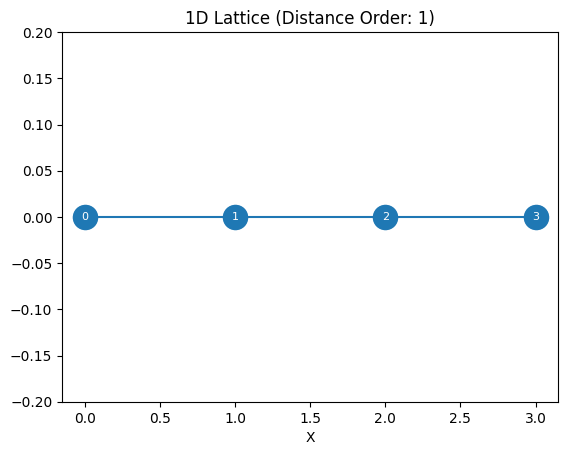

<Axes: title={'center': '1D Lattice (Distance Order: 1)'}, xlabel='X'>

In [2]:
g.draw()

In [3]:

L = 4 
D = 1
t = 1.0  # tunneling/hopping
U = 0.1  # coulomb

# create the graph our fermions can hop on
g = nk.graph.Hypercube(length=L, n_dim=D, pbc=False)
n_sites = g.n_nodes
# create a hilbert space with 2 up and 2 down spins
hilber_space = nk.hilbert.SpinOrbitalFermions(n_sites, s=1 / 2, n_fermions_per_spin=(2, 2))
def c(site, sz):
    return nk.operator.fermion.destroy(hilber_space, site, sz=sz)


def cdag(site, sz):
    return nk.operator.fermion.create(hilber_space, site, sz=sz)


def nc(site, sz):
    return nk.operator.fermion.number(hilber_space, site, sz=sz)

up = +1
down = -1
ham = 0.0
for sz in (up, down):
    for u, v in g.edges():
        ham += -t * cdag(u, sz) * c(v, sz) - t * cdag(v, sz) * c(u, sz)
for u in g.nodes():
    ham += U * nc(u, up) * nc(u, down)

print("Hamiltonian =", ham.operator_string())

Hamiltonian = -1.0 [4^ 5] +
-1.0 [5^ 4] +
-1.0 [5^ 6] +
-1.0 [6^ 5] +
-1.0 [6^ 7] +
-1.0 [7^ 6] +
-1.0 [0^ 1] +
-1.0 [1^ 0] +
-1.0 [1^ 2] +
-1.0 [2^ 1] +
-1.0 [2^ 3] +
-1.0 [3^ 2] +
0.1 [4^ 4 0^ 0] +
0.1 [5^ 5 1^ 1] +
0.1 [6^ 6 2^ 2] +
0.1 [7^ 7 3^ 3]


In [4]:
nk.exact.lanczos_ed(ham, k=3)

array([-4.37317565, -3.16663796, -3.1066282 ])

In [6]:
sampler = nk.sampler.MetropolisFermionHop(hilber_space, graph=g, n_chains=16, sweep_size=64)
# or let netket copy the graph per spin sector
saampler = nk.sampler.MetropolisFermionHop(
    hilber_space, graph=g, n_chains=16, sweep_size=64, spin_symmetric=True
)
# since the hilbert basis is a set of occupation numbers, we can take a general RBM
# we take complex parameters, since it learns sign structures more easily, and for even fermion number, the wave function might be complex
model1 = nk.models.RBM(alpha=1, param_dtype=complex, use_visible_bias=False)



vs1 = nk.vqs.MCState(sampler, model1, n_discard_per_chain=10, n_samples=512)

# we will use sgd with Stochastic Reconfiguration
opt = nk.optimizer.Sgd(learning_rate=0.01)
sr = nk.optimizer.SR(diag_shift=0.1, holomorphic=False)
gs = nk.driver.VMC(ham, opt, variational_state=vs1, preconditioner=sr)



In [7]:

class FFN(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        """
        Construct a Feed-Forward Neural Network with a single hidden layer.

        Args:
            N: The number of input nodes (number of spins in the chain).
            alpha: The density of the hidden layer. The hidden layer will have
                N*alpha nodes.
            rngs: The random number generator seed.
        """
        self.alpha = alpha

        # We define a linear (or dense) layer with `alpha` times the number of input nodes
        # as output nodes.
        # We must pass forward the rngs object to the dense layer.
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):

        # we apply the linear layer to the input
        y = self.linear(x)

        # the non-linearity is a simple ReLu
        y = nnx.relu(y)

        # sum the output
        return jnp.sum(y, axis=-1)
    


In [8]:
model2 = FFN(N=L*2, alpha=1, rngs=nnx.Rngs(2))
vstate2 = nk.vqs.MCState(sampler, model2, n_samples=1008)

In [9]:
gs2 = nk.driver.VMC(ham, opt, variational_state=vstate2, preconditioner=sr)
exp_name = "fermions_test0716_FNN"
gs2.run(500, out=exp_name)

100%|██████████| 500/500 [00:09<00:00, 53.04it/s, Energy=-4.3687 ± 0.0038 [σ²=0.0147, R̂=1.0090]]


(JsonLog('fermions_test0716_FNN', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.04459381103515625
   	Params: 0.04201221466064453,)

In [10]:
# now run the optimization
# first step will take longer in order to compile
exp_name = "fermions_test0716_RBM"
gs.run(500, out=exp_name)

100%|██████████| 500/500 [00:18<00:00, 26.66it/s, Energy=-4.3712-0.0000j ± 0.0023 [σ²=0.0027, R̂=1.0133]]


(JsonLog('fermions_test0716_RBM', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.07595705986022949
   	Params: 0.07312512397766113,)

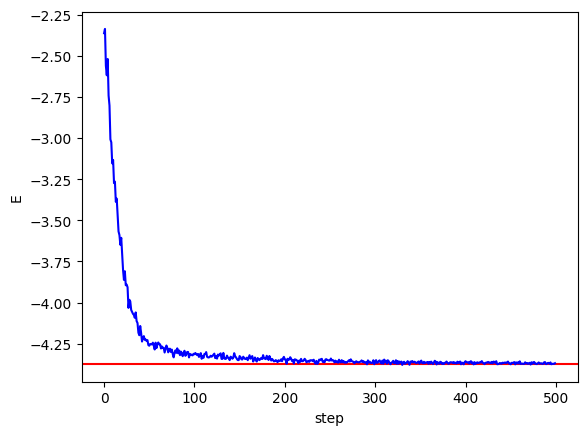

In [15]:
ed_energies = np.linalg.eigvalsh(ham.to_dense())

# with open('./fermions_test0716_RBM.log') as f:
#     data_RBM = json.load(f)
    
with open('./fermions_test0716_FNN.log') as f:
    data_FNN = json.load(f)
    

# x_RBM = data_RBM["Energy"]["iters"]
# y_RBM = data_RBM["Energy"]["Mean"]["real"]
x_FNN = data_FNN["Energy"]["iters"]
y_FNN = data_FNN["Energy"]["Mean"]

# plot the energy levels
plt.axhline(ed_energies[0], color="red", label="E0")
# for e in ed_energies[1:]:
# plt.axhline(e, color="black")
#plt.plot(x_RBM, y_RBM, color="red", label="VMC RBM")
plt.plot(x_FNN, y_FNN, color="blue", label="VMC FNN")
plt.xlabel("step")
plt.ylabel("E")
plt.show()

In [19]:
y_FNN[-5:]

[-4.374716541839261,
 -4.372806482430962,
 -4.372203120701608,
 -4.372488243783279,
 -4.368666557269911]

In [18]:
ed_energies[0]

-4.373175652558939